In [95]:
import pandas as pd
import numpy as np
from collections import deque, Counter
from tensorflow.keras.models import Sequential, clone_model
from tensorflow.keras.layers import Dense, InputLayer, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
import random
import time 
import tensorflow as tf
from Data_Preprocessing import Data_Preprocessing
from Calculate_Returns import Calculate_Returns
from Triple_Barrier_Labelel import Triple_Barrier_Labelel
from Model_Train import Model_Train, TextDataset
import torch
from torch.utils.data import DataLoader
from tensorflow import keras
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from datasets import Dataset as HuggingfaceDataset
import re
import os
import string
import gc
from Association_Rule_Mining import create_optimized_dataset, extend_time_columns, create_tweet_dataset, create_continous_dataset, create_triple_barrier_labeling, create_categorize_dataset


DEBUG = False

dp = Data_Preprocessing()
mt = Model_Train('', '')
encoder = OneHotEncoder(sparse=False)
scaler = MinMaxScaler()
tbl = Triple_Barrier_Labelel()

MEMORY_LENGTH = 100
BATCH_SIZE = 64
MODEL_DESIGN = "64/64"
LEARNING_RATE = 0.0005
FEE = 0.01
INITIAL_CASH = 100000
TARGET_UPDATE = 20
EPISODES = 50
EPSILON_MIN = 0.01
EPSILON_DECAY = 0.95
GAMMA = 0.95
EPSILON = 1.0
# MARKET = "BTC-USD"
# STARTING_DATE = "2021-04-01"
# ENDING_DATE ="2025-08-01"

# BTC_USD_TWEET_ID = '67082fb60891532d63a3ed67'
TWEETS_RANDOM_SAMPLE = True
TWEETS_ENGAGEMENT_POSTS = False
TWEETS_DAILY_SAMPLE_SIZE = 50
TWEETS_RANDOM_SEED = 42
TEST_REPEATS = 1

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

In [32]:
def evaluate_model(original_data, scaled_data, mod, log = False, market = "BTC"):
    print("Evaluating...")
    returns = Calculate_Returns(INITIAL_CASH, FEE, pd.Series([x[0] for x in original_data]), pd.Series(dtype="float64"), pd.Series(dtype="float64"), pd.Series(dtype="float64"))
    profits = []
    action = None
    
    def _append_action_and_position_to_state(state, action):
        one_hot_action = np.zeros(3)
        if action is not None:
            one_hot_action[action] = 1
        position_one_hot = np.zeros(3)
        position_index = int(returns.context)
        position_one_hot[position_index] = 1
        return np.concatenate([state, one_hot_action, position_one_hot])

    for step, element in enumerate(original_data[:-1]):
        offset = step
#         state = _append_action_and_position_to_state(scaled_data[offset], action)
#         q_values = mod.predict(np.array(state).reshape(1, -1), verbose=0)
        q_values = mod.predict(np.array(scaled_data[offset]).reshape(1,-1), verbose=0)
        action = np.argmax(q_values[0])
        offset += 1
        if log:
            print(f"Step: {offset}/{len(original_data[:-1])}, Prev Price: {original_data[offset - 1][0]}, Selected Action: {action}")
#         delta = (original_data[offset][0] - original_data[offset - 1][0]) / original_data[offset - 1][0]
#         if action == 0: #Hold
#             if returns.context == 0: #Keep holding
#                 reward = -abs(delta)
#             elif returns.context == 1: #Keep shorting
#                 reward = -delta
#             elif returns.context == 2: #Keep loning
#                 reward = delta
#         elif action == 1: #Short
#             if returns.context == 0: #Open short
#                 reward = -delta - FEE
#             elif returns.context == 1: #Keep shorting
#                 reward = -delta
#             elif returns.context == 2: #Switch to long
#                 reward = delta - 2*FEE
#         elif action == 2: #Long
#             if returns.context == 0: #Open long
#                 reward = delta - FEE
#             elif returns.context == 1: #Switch to short
#                 reward = - delta - 2*FEE
#             elif returns.context == 2: #Keep longing
#                 reward = delta
#         reward = float(returns.returns[-1])
        delta = ((original_data[offset][0] - original_data[offset - 1][0]) / original_data[offset - 1][0])        
        if action == 0: #Hold
            reward = -0.01
        elif action == 1: #Short
            reward = -delta
        else: #Long
            reward = delta
        returns.perform_action(action, offset)
        if log:
            print(f"Next Price: {original_data[offset][0]}, Reward: {reward}\n")
        profits.append(reward)
    positive_rewards = (len([p for p in profits if p > 0])/len(profits))*100
    if len(returns.records):
        wins = (len([e['PnL'] for e in returns.records if e['PnL'] > 0])/len(returns.records))*100
        sum_pnl = sum([e['PnL'] for e in returns.records])
        days = 365 if market == "BTC" else 252
        sharpe_ratio = returns.sharpe(days)

    if log and len(returns.records):
        print(f"Positive Rewards {positive_rewards}")
        print(f"Wins {wins}")
        print(f"Sum PnL {sum_pnl}")
        print(f"Sharpe Ratio {sharpe_ratio}")
        
    return {
        "Positive Rewards": positive_rewards,
        "Wins": wins if len(returns.records) else 0,
        "Sum PnL": sum_pnl if len(returns.records) else 0,
        "Sharpe Ratio": sharpe_ratio if len(returns.records) else 0
    }

In [33]:
class Agent():
    def __init__(self, action_size, state_size, gamma, epsilon, epsilon_min, epsilon_decay, model_id = 0):
        self.action_size = action_size
        self.state_size = state_size
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_min = epsilon_min
        self.epsilon_decay = epsilon_decay
        self.memory = deque(maxlen=MEMORY_LENGTH)
        self.model = self.create_model()
        self.target_model = clone_model(self.model)
        self.optimizer = Adam(learning_rate=LEARNING_RATE) 
        self.step_counter = 0
        
    def generate_model(self, state_size, action_size):
        layers = MODEL_DESIGN.split("/")
        model = Sequential()
        state_size = state_size
        model.add(InputLayer(input_shape=(state_size,), name="InputLayer"))
        for index, units in enumerate(layers):
            model.add(Dense(units=units, activation="relu", name=f"HiddenLayer{index}"))
            model.add(Dropout(0.1))
        model.add(Dense(units=action_size, activation='linear', name="OutputLayer"))
        return model

    def create_model(self):
        return self.generate_model(self.state_size, self.action_size)

    def act(self, state):
        if random.uniform(0,1) < self.epsilon:
            rand_action = random.randrange(self.action_size)
            return rand_action
        state = np.array(state).reshape(1, -1)
#         q_values = self.model.predict([state], verbose=0)
        q_values = self.model(np.array(state, dtype=np.float32), training=False).numpy()
        return np.argmax(q_values[0])
    
    def remember(self, state, action, reward, new_state, done):
        self.memory.append((state, action, reward, new_state, done))
        
    def update_target_model(self):
        self.target_model.set_weights(self.model.get_weights())
    
    def replay(self, step):
        if len(self.memory) < BATCH_SIZE:
            return
        minibatch = random.sample(self.memory, BATCH_SIZE)
        states, actions, rewards, new_states, done = zip(*minibatch)
        states = np.array(states, dtype=np.float32)
        new_states = np.array(new_states, dtype=np.float32)
        actions = np.array(actions, dtype=np.int32)
        rewards = np.array(rewards, dtype=np.float32)
        done = np.array(done, dtype=np.float32)
#         states = np.array([sample[0] for sample in minibatch], dtype=np.float32).reshape(BATCH_SIZE, self.state_size)
#         actions = np.array([sample[1] for sample in minibatch], dtype=np.int32)
#         rewards = np.array([sample[2] for sample in minibatch], dtype=np.float32)
#         new_states = np.array([sample[3] for sample in minibatch], dtype=np.float32).reshape(BATCH_SIZE, self.state_size)
#         done = np.array([sample[4] for sample in minibatch])

        best_action_indices = np.argmax(self.model(new_states, training=False).numpy(), axis=1)
        target = rewards + (1 - done) * self.gamma * self.target_model(new_states, training=False).numpy()[np.arange(BATCH_SIZE), best_action_indices]
#         best_action_indices = np.argmax(self.model.predict([new_states], verbose=0), axis=1)
#         target = rewards + (1 - done) * self.gamma * self.target_model.predict([new_states], verbose=0)[np.arange(BATCH_SIZE), best_action_indices]
        with tf.GradientTape() as tape:
            current_Q_values = self.model([states], training=True)
            action_mask = tf.one_hot(actions, current_Q_values.shape[1])
            predicted_Q_values = tf.reduce_sum(current_Q_values * action_mask, axis=1)
            loss = tf.keras.losses.MeanSquaredError()(target, predicted_Q_values)
        gradients = tape.gradient(loss, self.model.trainable_variables)
        self.optimizer.apply_gradients(zip(gradients,self.model.trainable_variables))
        self.step_counter += 1
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay
        if self.step_counter % TARGET_UPDATE == 0:
            self.step_counter = 0
            self.update_target_model()
        del states, actions, rewards, new_states, done, minibatch
        gc.collect()

In [34]:
class Environment():
    def __init__(self, data, data_scaled):
        self.action_size = 3
        self.state_size = np.array(data_scaled).shape[1] # + self.action_size + 3 #Context size
        self.data = data
        self.data_scaled = data_scaled
        self.offset = 0
        self.steps = len(data)
        self.returns = Calculate_Returns(INITIAL_CASH, FEE, pd.Series([x[0] for x in data]), pd.Series(dtype="float64"), pd.Series(dtype="float64"), pd.Series(dtype="float64"))
    
    def _append_action_and_position_to_state(self, state, action):
        one_hot_action = np.zeros(self.action_size)
        if action is not None:
            one_hot_action[action] = 1
        position_one_hot = np.zeros(3)
        position_index = int(self.returns.context)
        position_one_hot[position_index] = 1
        return np.concatenate([state, one_hot_action, position_one_hot])
    
    def step(self, action):
        self.offset = self.offset + 1
        new_state = self.data_scaled[self.offset]
#         new_state = self._append_action_and_position_to_state(new_state, action)
        delta = ((self.data[self.offset][0] - self.data[self.offset - 1][0]) / self.data[self.offset - 1][0])
        if action == 0: #Hold
            reward = -0.01
        elif action == 1: #Short
            reward = -delta
        else: #Long
            reward = delta
#         if action == 0: #Hold
#             if self.returns.context == 0: #Keep holding
#                 reward = -abs(delta)
#             elif self.returns.context == 1: #Keep shorting
#                 reward = -delta
#             elif self.returns.context == 2: #Keep loning
#                 reward = delta
#         elif action == 1: #Short
#             if self.returns.context == 0: #Open short
#                 reward = -delta - FEE
#             elif self.returns.context == 1: #Keep shorting
#                 reward = -delta
#             elif self.returns.context == 2: #Switch to long
#                 reward = delta - 2*FEE
#         elif action == 2: #Long
#             if self.returns.context == 0: #Open long
#                 reward = delta - FEE
#             elif self.returns.context == 1: #Switch to short
#                 reward = - delta - 2*FEE
#             elif self.returns.context == 2: #Keep longing
#                 reward = delta
        self.returns.perform_action(action, self.offset)
#         reward = float(self.returns.returns[-1])
        done = self.offset == len(self.data) - 1
        return new_state, reward, done
    
    def reset(self):
        self.offset = 0
        self.returns = Calculate_Returns(INITIAL_CASH, FEE, pd.Series([x[0] for x in self.data]), pd.Series(dtype="float64"), pd.Series(dtype="float64"), pd.Series(dtype="float64"))
        state_only = self.data_scaled[self.offset]
#         return self._append_action_and_position_to_state(state_only, action=None)
        return state_only

In [35]:
class DQNAlgorithm():
    def __init__(self, data, data_scaled, episodes, gamma, epsilon, epsilon_min, epsilon_decay):
        self.episodes = episodes
        self.data = data
        self.data_scaled = data_scaled
        self.env = Environment(data, data_scaled)
        self.steps = self.env.steps
        self.agent = Agent(self.env.action_size, self.env.state_size, gamma, epsilon, epsilon_min, epsilon_decay)
        self.best_model_win_rate = 0
        encoder.fit([[0], [1], [2]])
        self.best_model = None
        self.best_models = []
        
    def debug(self, train_data):
        print("Debugging...")
        state = self.env.reset()
        profits = []
        balances = []
        for step in range(self.steps):
            action = self.agent.act(state)
            new_state, reward, done = self.env.step(action)
            print(f"Step: {step}/{self.steps}, Prev Price: {self.data[step][0]}, Previous Context: {self.env.returns.context}, Selected Action: {action}")
            print(f"Next Price: {self.data[step + 1][0]}, Reward: {reward}\n")
            self.agent.remember(state, action, reward, new_state, done)
            profits.append(reward)
            if done == True:
                pos_rewards = (len([p for p in profits if p > 0])/len(profits))*100
                if pos_rewards > self.best_model_win_rate:
                    self.best_model_win_rate = pos_rewards
                    self.best_model = self.agent.model
                print(f"Positive Rewards: {pos_rewards} %")
                if len(self.env.returns.records):
                    print(f"Wins: {(len([e['PnL'] for e in self.env.returns.records if e['PnL'] > 0])/len(self.env.returns.records))*100} %")
                    print(f"Sum PnL: {sum([e['PnL'] for e in self.env.returns.records])}")
                print(f"Sharpe Ratio: {self.env.returns.sharpe()}")
                break
            self.agent.replay(step)
            state = new_state
            
    def copy_and_store(self):
        new_model = clone_model(self.agent.model)
        new_model.set_weights(self.agent.model.get_weights())
        self.best_model = new_model

    def run(self, market, validate_y=None, validate_scaled=None):
        print("Training...")
        for episode in range(self.episodes):
            state = self.env.reset()
            actions = 0
            start_time = time.time()
            for step in range(self.steps):
                actions+=1
                action = self.agent.act(state)
                new_state, reward, done = self.env.step(action)
                self.agent.remember(state, action, reward, new_state, done)
                if done == True:
                    # model_returns_train = evaluate_model(self.data, self.data_scaled, self.agent.model, False, market)
                    # print(model_returns_train)
                    new_model = clone_model(self.agent.model)
                    new_model.set_weights(self.agent.model.get_weights())
                    self.best_models.append(new_model)
                    # if model_returns_validate["Positive Rewards"] > self.best_model_win_rate:
                    #     self.best_model_win_rate = model_returns_validate["Positive Rewards"]
                    #     self.copy_and_store()
                    print(f"Episode {episode + 1}/{self.episodes}")
                    # print(f"Positive Rewards: {model_returns_validate['Positive Rewards']} %")
#                     if len(self.env.returns.records):
#                         print(f"Wins: {(len([e['PnL'] for e in self.env.returns.records if e['PnL'] > 0])/len(self.env.returns.records))*100} %")
#                         print(f"Sum PnL: {sum([e['PnL'] for e in self.env.returns.records])}")
#                     days = 365 if market == "BTC" else 252
#                     print(f"Sharpe Ratio: {self.env.returns.sharpe(days)}")
                    end_time = time.time()
                    print(f"Elapsed time: {end_time - start_time}\n")
                    break
                self.agent.replay(step)
                state = new_state
        print("Cleaning memory...")
        gc.collect()
        tf.keras.backend.clear_session()
        return self.best_model, self.best_models

In [36]:
def process_dataset_with_sentiment(labeled_df, tweets_id, market):
    tweet_df = dp.load_tweet_data(tag_id = tweets_id, random_sample = TWEETS_RANDOM_SAMPLE, engagement_posts = TWEETS_ENGAGEMENT_POSTS, daily_sample_size = TWEETS_DAILY_SAMPLE_SIZE, random_seed = TWEETS_RANDOM_SEED)
    merged_df = dp.merge_data(labeled_df, tweet_df)
    merged_df["content"] = merged_df["content"].apply(lambda t: dp.apply_transformations(t, transformations=["TEXT_TO_LOWER", "REMOVE_URLS", "REMOVE_USERNAMES", "REMOVE_PUNCTUATION_WITH_EXCLUDE", "REMOVE_EMOTICONS", f"REPLACE_WITH_{market}"]))
    merged_df["text"] = dp.generate_tweet_prompts(merged_df)
    label_map = {
        0: "Bearish",
        1: "Neutral",
        2: "Bullish"
    }       
    model = AutoModelForSequenceClassification.from_pretrained(
        "Models/btcusd_model",
        trust_remote_code=True
    )
    tokenizer = AutoTokenizer.from_pretrained("ProsusAI/finbert")

    mapped_df = pd.DataFrame(columns=['prediction'])#, 'confidence'])  
    for index, group in merged_df.groupby(merged_df.index):
        preds = mt.predict(model, tokenizer, list(group["text"]))
        counter = Counter(preds.tolist())
        most_common, count = counter.most_common(1)[0]
        confidence = count / len(preds)
        mapped_df.loc[index] = {
            "prediction": most_common,
            "confidence": round(confidence, 2),
        }
    mapped_df['prediction'] = mapped_df['prediction'].map(label_map)
    mapped_df['prediction_t-1'] = mapped_df['prediction'].shift(1)
    mapped_df['prediction_t-2'] = mapped_df['prediction'].shift(2)
    mapped_df['prediction_t-3'] = mapped_df['prediction'].shift(3)
    
    mapped_df = mapped_df.dropna()
    
    # One-hot encode 'Prediction'
    one_hot_prediction = pd.DataFrame(
        encoder.fit_transform(mapped_df[['prediction']]),
        columns=encoder.get_feature_names_out(['prediction']),
        index=mapped_df.index
    )
    # One-hot encode 'Prediction'
    one_hot_prediction_1 = pd.DataFrame(
        encoder.fit_transform(mapped_df[['prediction_t-1']]),
        columns=encoder.get_feature_names_out(['prediction_t-1']),
        index=mapped_df.index
    )
    # One-hot encode 'Prediction'
    one_hot_prediction_2 = pd.DataFrame(
        encoder.fit_transform(mapped_df[['prediction_t-2']]),
        columns=encoder.get_feature_names_out(['prediction_t-2']),
        index=mapped_df.index
    )
        # One-hot encode 'Prediction'
    one_hot_prediction_3 = pd.DataFrame(
        encoder.fit_transform(mapped_df[['prediction_t-3']]),
        columns=encoder.get_feature_names_out(['prediction_t-3']),
        index=mapped_df.index
    )
    # Concatenate one-hot columns
    merged_data = pd.concat([labeled_df, mapped_df, one_hot_prediction, one_hot_prediction_1, one_hot_prediction_2, one_hot_prediction_3], axis=1)
    # Drop the original categorical columns (optional)
    dataset = merged_data.drop(columns=['prediction', 'prediction_t-1', 'prediction_t-2', 'prediction_t-3', 'ROC', 'RSI', 'previous_label'])
    dataset = dataset.dropna()
    return dataset

In [37]:
def get_Tweets_Id(market):
    if market == "BTC-USD":
        return "67082fb60891532d63a3ed67"
    elif market == "NVDA":
        return "67082fb60891532d63a3ed68"
    elif market == "GOOGL":
        return "67082fb70891532d63a3ed69"
    elif market == "AMZN":
        return "67082fb70891532d63a3ed6a"
    elif market == "AAPL":
        return "67082fb70891532d63a3ed6b"
    elif market == "MSFT":
        return "67082fb70891532d63a3ed6c"
    elif market == "TSLA":
        return "67082fb70891532d63a3ed6d"
    elif market == "SPY":
        return "67082fb70891532d63a3ed6e"
    else:
        return "67082fb70891532d63a3ed6f"
    
def extract_text(s):
    # Match only letters at the start until a non-alphabetic character
    match = re.match(r"[A-Za-z]+", s)
    return match.group(0) if match else ""

In [99]:
STARTING_DATE = "2018-01-01"
ENDING_DATE ="2019-01-01"

In [39]:
cases = pd.read_csv("TestCases/TestCases_2.csv")
for test_id in range(25, len(cases)):
    params = cases["Parameters"][test_id]
    market = cases["Market"][test_id]
    name = cases["TestCaseName"][test_id]
    
    continous_df = create_continous_dataset(market, starting_date=STARTING_DATE, ending_date=ENDING_DATE)
    continous_df_with_tbl = create_triple_barrier_labeling(continous_df)
    tweets_df = create_tweet_dataset("Datasets/investing_classified_sentiments" if market != "BTC-USD" else "Datasets/btc_classified_sentiments") #"Datasets/investing_classified_sentiments"
    merged_df = pd.concat([continous_df_with_tbl, tweets_df], axis=1).dropna()
    # extended = merged_df #extend_time_columns(merged_df, skip_cols=["signals"], t=7)
    categorized_for_trade_profitable = create_categorize_dataset(merged_df, suffix_vals=['bearish', 'Bearish', 'bullish', 'Bullish', '1.0', '1', '0.0', '0', '-1', '-1.0'], skip_cols=["next_day_label", "signals", "previous_label"])
    merged_df = pd.concat([merged_df, categorized_for_trade_profitable], axis=1).dropna()

    # continous_df = create_continous_dataset(market)
    # continous_df_with_tbl = create_triple_barrier_labeling(continous_df)
    # merged_df = pd.concat([continous_df_with_tbl, tweets_df], axis=1).dropna()
    # extended = extend_time_columns(merged_df, t=7)
    # categorized_for_close = create_categorize_dataset(extended, suffix_vals=['bullish', 'Bullish', '1', '1.0'])
    # merged_df = pd.concat([extended, categorized_for_close], axis=1).dropna()

    sel_param = ["close"] + [el.strip() for el in params.split(",")]
    
    existing_cols = [col for col in sel_param if col in merged_df.columns]
    merged_data = merged_df[existing_cols]
    
    merged_data = merged_data.values.tolist()
    train_end = int(len(merged_data) * 0.8)
    # val_end = int(len(merged_data) * 0.8)
    train_data = merged_data[:train_end]
    # val_data = merged_data[train_end:val_end]
    test_data  = merged_data[train_end:]#[val_end:]
    train_x = np.array(train_data)[:,1:]
    train_y = np.array(train_data)[:,:1]
    # val_x = np.array(val_data)[:, 1:]
    # val_y = np.array(val_data)[:, :1]
    test_x = np.array(test_data)[:,1:]
    test_y = np.array(test_data)[:,:1]
    scaler.fit(train_x)
    train_scaled = scaler.transform(train_x).tolist()
    # val_scaled = scaler.transform(val_x).tolist()
    test_scaled = scaler.transform(test_x).tolist()
    
    for rep in range(0,4):
        best_models = []

        for repeat in range(TEST_REPEATS):
            dqn = DQNAlgorithm(data=train_y, data_scaled=train_scaled, episodes=EPISODES, gamma=GAMMA, epsilon=EPSILON, epsilon_min=EPSILON_MIN, epsilon_decay = EPSILON_DECAY)
            if DEBUG == True:
                dqn.debug(train_data)
                break
            else:
                best_model, best_models = dqn.run(market)#, val_y, val_scaled)
                # best_models.append(best_model)

        test_results = {
            "Positive Rewards": -np.inf,
            "Wins": -np.inf,
            "Sum PnL": -np.inf,
            "Sharpe Ratio": -np.inf
        }
        
        for index, model in enumerate(best_models):
            print(f"Model {index}")
            score = evaluate_model(test_y, test_scaled, model, False, market)
            if score["Positive Rewards"] > test_results["Positive Rewards"]:
                test_results = score
                
        # for model in best_models:        
        #     model_returns_test = evaluate_model(test_y, test_scaled, best_model, True, market)
        #     test_results.append(model_returns_test)
            
        test_results_df = pd.DataFrame([test_results])

        columns = ["TestCaseName", "Market", "Parameters", "Positive Rewards", "Wins", "Sum PnL", "Sharpe Ratio"]
        test_conc = [name, market, params, f"Mean: {test_results_df['Positive Rewards'].mean()}, Std: {test_results_df['Positive Rewards'].std()}", f"Mean: {test_results_df['Wins'].mean()}, Std: {test_results_df['Wins'].std()}", f"Mean: {pd.to_numeric(test_results_df['Sum PnL'], errors='coerce').mean()}, Std: {pd.to_numeric(test_results_df['Sum PnL'], errors='coerce').std()}", f"Mean: {test_results_df['Sharpe Ratio'].mean()}, Std: {test_results_df['Sharpe Ratio'].std()}"]
        pd.DataFrame([test_conc], columns=columns).to_csv(f"TestResults/DDQN_Test_Results_2.csv", mode="a", index=False, header=not os.path.exists("TestResults/DDQN_Test_Results.csv"))


[*********************100%***********************]  1 of 1 completed


Optimizing:   0%|          | 0/5 [00:00<?, ?it/s]

Label distribution: 
2.0    62
1.0    34
0.0    26
Name: label, dtype: int64 0    2.994185
Name: sharpe_ratio, dtype: float64
Training...
Episode 1/50
Elapsed time: 5.907172918319702

Episode 2/50
Elapsed time: 21.734497547149658

Episode 3/50
Elapsed time: 21.617183208465576

Episode 4/50
Elapsed time: 21.604122161865234

Episode 5/50
Elapsed time: 22.160839796066284

Episode 6/50
Elapsed time: 21.576419591903687

Episode 7/50
Elapsed time: 21.45049262046814

Episode 8/50
Elapsed time: 21.634766340255737

Episode 9/50
Elapsed time: 21.59031629562378

Episode 10/50
Elapsed time: 21.574276208877563

Episode 11/50
Elapsed time: 21.453062295913696

Episode 12/50
Elapsed time: 21.5141384601593

Episode 13/50
Elapsed time: 21.969374895095825

Episode 14/50
Elapsed time: 21.90931224822998

Episode 15/50
Elapsed time: 21.937182426452637

Episode 16/50
Elapsed time: 22.09203314781189

Episode 17/50
Elapsed time: 21.903541803359985

Episode 18/50
Elapsed time: 21.864092111587524

Episode 19/50


[*********************100%***********************]  1 of 1 completed


Optimizing:   0%|          | 0/5 [00:00<?, ?it/s]

Label distribution: 
2.0    74
0.0    25
1.0    16
Name: label, dtype: int64 0    2.171282
Name: sharpe_ratio, dtype: float64
Training...
Episode 1/50
Elapsed time: 4.67418360710144

Episode 2/50
Elapsed time: 20.60124444961548

Episode 3/50
Elapsed time: 20.770009756088257

Episode 4/50
Elapsed time: 20.617114067077637

Episode 5/50
Elapsed time: 20.57311463356018

Episode 6/50
Elapsed time: 21.14498019218445

Episode 7/50
Elapsed time: 21.09333825111389

Episode 8/50
Elapsed time: 21.197298288345337

Episode 9/50
Elapsed time: 21.19319200515747

Episode 10/50
Elapsed time: 21.108577966690063

Episode 11/50
Elapsed time: 21.28349018096924

Episode 12/50
Elapsed time: 21.239773750305176

Episode 13/50
Elapsed time: 21.50540328025818

Episode 14/50
Elapsed time: 21.119394540786743

Episode 15/50
Elapsed time: 21.154077768325806

Episode 16/50
Elapsed time: 21.820578813552856

Episode 17/50
Elapsed time: 21.322994709014893

Episode 18/50
Elapsed time: 21.10887360572815

Episode 19/50
Ela

In [101]:
def evaluate_buy_and_hold(market_data):
    df = market_data.copy()
    df["Return"] = df["close"].pct_change()
    df = df.dropna()

    # Buy once, hold all the way
    cumulative_return = (1 + df["Return"]).prod() - 1

    # Win rate = fraction of days with positive daily return
    win_rate = (df["Return"] > 0).mean() * 100

    return cumulative_return * 100, win_rate


In [105]:
def evaluate_sma_crossover(market_data, short_window=10, long_window=30):
    df = market_data.copy()
    df["SMA_Short"] = df["close"].rolling(window=short_window).mean()
    df["SMA_Long"] = df["close"].rolling(window=long_window).mean()
    df = df.dropna()

    # Position: 1 = long, -1 = short (you can also use 0 for flat if you prefer)
    df["Position"] = np.where(df["SMA_Short"] > df["SMA_Long"], 1, -1)

    # Daily returns
    df["Return"] = df["close"].pct_change()
    df["Strategy_Return"] = df["Position"].shift(1) * df["Return"]

    # Metrics
    cumulative_return = (1 + df["Strategy_Return"]).prod() - 1
    win_rate = (df["Strategy_Return"] > 0).mean() * 100

    return cumulative_return * 100, win_rate

def optimize_crossover(dataset):
    shorts = list(range(5,20))
    longs = list(range(20,50))

    best = 0
    short_wind = 0
    long_wind = 0

    for s in shorts:
        for l in longs:
            win_rate = evaluate_sma_crossover(pd.DataFrame(dataset, columns=["close"]), s, l)[1]
            if win_rate > best:
                best = win_rate
                short_wind = s
                long_wind = l
    print(best, short_wind, long_wind)


btc_df = create_continous_dataset('BTC-USD', starting_date=STARTING_DATE, ending_date=ENDING_DATE)
optimize_crossover(btc_df)
print(evaluate_buy_and_hold(btc_df))

amzn_df = create_continous_dataset('AMZN', starting_date=STARTING_DATE, ending_date=ENDING_DATE)
optimize_crossover(amzn_df)
print(evaluate_buy_and_hold(amzn_df))

msft_df = create_continous_dataset('MSFT', starting_date=STARTING_DATE, ending_date=ENDING_DATE)
optimize_crossover(msft_df)
print(evaluate_buy_and_hold(msft_df))

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

51.35135135135135 16 21
(-66.65834762034389, 50.79365079365079)



[*********************100%***********************]  1 of 1 completed

60.22727272727273 19 27
(-5.5958513742211835, 53.73134328358209)


55.688622754491014 5 36
(9.584664003701548, 54.72636815920397)


In [42]:
# labeled_df = pd.DataFrame(columns=["RSI", "ROC", "Volatility" ,"Crossover", "Close_Increasing" , "Momentum", "MACD"])

# rsi = pd.DataFrame()
# optimized_params_rsi = pd.DataFrame(optimize_param(merged_df, param_grid_rsi, rsi_signal_gen))
# for _, row in optimized_params_rsi.iterrows():
#     start, end, params = row['start'], row['end'], row['params']
#     interval_df = merged_df.loc[start:end]
#     _, transformed = dp.calculate_rsi(interval_df["close"], params["RSI_Window"], (params["Down_Threshold"], params["Up_Threshold"]))
#     rsi = pd.concat([rsi, transformed])

# roc = pd.DataFrame()
# optimized_params_roc = pd.DataFrame(optimize_param(merged_df, param_grid_roc, roc_signal_gen))
# for _, row in optimized_params_roc.iterrows():
#     start, end, params = row['start'], row['end'], row['params']
#     interval_df = merged_df.loc[start:end]
#     _, transformed = dp.calculate_returns(interval_df["close"], params["ROC_Window"])
#     roc = pd.concat([roc, transformed])
    
# vol = pd.DataFrame()   
# optimized_params_vol = pd.DataFrame(optimize_param(merged_df, param_grid_roc, volatility_signal_gen))
# for _, row in optimized_params_vol.iterrows():
#     start, end, params = row['start'], row['end'], row['params']
#     interval_df = merged_df.loc[start:end]
#     _, transformed = tbl.get_daily_volatility(interval_df, params['ROC_Window'])
#     vol = pd.concat([vol, transformed])
    

# close_increasing = pd.DataFrame()   
# optimized_params_close = pd.DataFrame(optimize_param(merged_df, params_grid_close_increasing, close_increasing_signal_gen))
# for _, row in optimized_params_close.iterrows():
#     start, end, params = row['start'], row['end'], row['params']
#     interval_df = merged_df.loc[start:end]
#     interval_df["close_increasing"] = np.where(interval_df["close"].shift(params["t"]) < interval_df["close"], 1, 0)
#     transformed = interval_df["close_increasing"]
#     close_increasing = pd.concat([close_increasing, transformed])

# momentum = pd.DataFrame()   
# optimized_params_momentum = pd.DataFrame(optimize_param(merged_df, params_grid_momentum, momentum_signal_gen))
# for _, row in optimized_params_momentum.iterrows():
#     start, end, params = row['start'], row['end'], row['params']
#     interval_df = merged_df.loc[start:end]
#     interval_df["Momentum_Val"] = interval_df["close"] - interval_df["close"].diff(params["t"])
#     interval_df["Momentum"] = np.where((interval_df["Momentum_Val"].shift(1) < interval_df["Momentum_Val"]).astype(int), 1, 0)
#     transformed = interval_df["Momentum"]
#     momentum = pd.concat([momentum, transformed])

# macd = pd.DataFrame()   
# optimized_params_macd = pd.DataFrame(optimize_param(merged_df, params_macd, macd_signal_gen))
# for _, row in optimized_params_macd.iterrows():
#     start, end, params = row['start'], row['end'], row['params']
#     interval_df = merged_df.loc[start:end]
#     interval_df["MACD_Val"] = ta.macd(interval_df["close"], length=params["Window"])['MACD_12_26_9']
#     interval_df["MACD"] = np.where(((interval_df["MACD_Val"].shift(1) < interval_df["MACD_Val"])).astype(int), 1, 0)
#     transformed = interval_df["MACD"]
#     macd = pd.concat([macd, transformed])
    
# # labeled_df["ROC"] = roc
# # labeled_df["RSI"] = rsi
# # labeled_df["Volatility"] = vol
# # labeled_df["Crossover"] = crossover
# # labeled_df["Close_Increasing"] = close_increasing
# # labeled_df["Momentum"] = momentum
# # labeled_df["MACD"] = macd
# # labeled_df



In [43]:
# cases = pd.read_csv("TestCases/DDQN_Test_Cases_Old.csv")
# for test_id in range(0, len(cases)):
    
#     params = cases["Parameters"][test_id]
    
#     print(params)
    
#     continous_df = create_continous_dataset('BTC-USD')
#     continous_df_with_tbl = create_triple_barrier_labeling(continous_df)
#     tweets_df = create_tweet_dataset() #"Datasets/investing_classified_sentiments"
#     merged_df = pd.concat([continous_df_with_tbl, tweets_df], axis=1).dropna()
#     extended = extend_time_columns(merged_df, t=7)
#     categorized_for_close = create_categorize_dataset(extended, suffix_vals=['bullish', 'Bullish', '1.0', '1'])
#     merged_df = pd.concat([extended, categorized_for_close], axis=1).dropna()
        
    # merged_data = merged_data.drop(merged_data.columns[0], axis=1)
    # merged_data = merged_data.values.tolist()
    # train_end = int(len(merged_data) * 0.6)
    # val_end = int(len(merged_data) * 0.8)
    # train_data = merged_data[:train_end]
    # val_data = merged_data[train_end:val_end]
    # test_data = merged_data[val_end:]
    # train_x = np.array(train_data)[:,1:]
    # train_y = np.array(train_data)[:,:1]
    # val_x = np.array(val_data)[:, 1:]
    # val_y = np.array(val_data)[:, :1]
    # test_x = np.array(test_data)[:,1:]
    # test_y = np.array(test_data)[:,:1]
    # scaler.fit(train_x)
    # train_scaled = scaler.transform(train_x).tolist()
    # val_scaled = scaler.transform(val_x).tolist()
    # test_scaled = scaler.transform(test_x).tolist()

    # best_models = []

    # for repeat in range(TEST_REPEATS):
    #     dqn = DQNAlgorithm(data=train_y, data_scaled=train_scaled, episodes=EPISODES, gamma=GAMMA, epsilon=EPSILON, epsilon_min=EPSILON_MIN, epsilon_decay = EPSILON_DECAY)
    #     if DEBUG == True:
    #         dqn.debug(train_data)
    #     else:
    #         best_model = dqn.run(cases['Market'][test_id], val_y, val_scaled)
    #         best_models.append(best_model)

    # test_results = []        
            
    # for model in best_models:        
    #     model_returns_test = evaluate_model(test_y, test_scaled, best_model, True, cases['Market'][test_id])
    #     test_results.append(model_returns_test)
        
    # test_results_df = pd.DataFrame(test_results)

    # columns = ["TestCaseName", "Market", "MarketRegime", "Parameters", "Positive Rewards", "Wins", "Sum PnL", "Sharpe Ratio"]
    # test_conc = [cases["TestCaseName"][test_id], cases["Market"][test_id], cases["MarketRegime"][test_id], cases["Parameters"][test_id], f"Mean: {test_results_df['Positive Rewards'].mean()}, Std: {test_results_df['Positive Rewards'].std()}", f"Mean: {test_results_df['Wins'].mean()}, Std: {test_results_df['Wins'].std()}", f"Mean: {test_results_df['Sum PnL'].mean()}, Std: {test_results_df['Sum PnL'].std()}", f"Mean: {test_results_df['Sharpe Ratio'].mean()}, Std: {test_results_df['Sharpe Ratio'].std()}"]
    # pd.DataFrame([test_conc], columns=columns).to_csv(f"TestResults/DDQN_Test_Results.csv", mode="a", index=False, header=not os.path.exists("TestResults/DDQN_Test_Results.csv"))

In [44]:
# cases = pd.read_csv("TestCases/DDQN_Test_Cases_Old.csv")
# # for test_id in range(0, len(cases)):
# test_id = 4
# #     if test_id == 0 or test_id == 2 or test_id == 4:
# #         continue
# #     if test_id == 6:
# #         break
# path_name = f"Datasets/{extract_text(cases['Market'][test_id]).lower()}_processed_data.csv"
# if os.path.exists(path_name):
#     merged_data = pd.read_csv(path_name)
# else:
#     price_df = dp.load_stock_data(cases["Market"][test_id], STARTING_DATE, ENDING_DATE)
#     labeled_df = dp.add_optimized_labels(price_df)
#     labeled_df = dp.add_target_label(labeled_df)
#     labeled_df = dp.add_technical_indicators(labeled_df).dropna()
#     labeled_df['RSI_t-1'] = labeled_df['RSI'].shift(1)
#     labeled_df['RSI_Value_t-1'] = labeled_df['RSI_Value'].shift(1)
#     labeled_df['RSI_t-2'] = labeled_df['RSI'].shift(2)
#     labeled_df['RSI_Value_t-2'] = labeled_df['RSI_Value'].shift(2)
#     labeled_df['RSI_t-3'] = labeled_df['RSI'].shift(3)
#     labeled_df['RSI_Value_t-3'] = labeled_df['RSI_Value'].shift(3)
#     labeled_df['ROC_t-1'] = labeled_df['ROC'].shift(1)
#     labeled_df['ROC_Value_t-1'] = labeled_df['ROC_Value'].shift(1)
#     labeled_df['ROC_t-2'] = labeled_df['ROC'].shift(2)
#     labeled_df['ROC_Value_t-2'] = labeled_df['ROC_Value'].shift(2)
#     labeled_df['ROC_t-3'] = labeled_df['ROC'].shift(3)
#     labeled_df['ROC_Value_t-3'] = labeled_df['ROC_Value'].shift(3)
#     labeled_df['volatility_t-1'] = labeled_df['volatility'].shift(1)
#     labeled_df['volatility_t-2'] = labeled_df['volatility'].shift(2)
#     labeled_df['volatility_t-3'] = labeled_df['volatility'].shift(3)
    
# #     #temp
# #     labeled_df['label_t-1'] = labeled_df['next_day_label'].shift(1)
# #     labeled_df['label_t-2'] = labeled_df['next_day_label'].shift(2)
# #     labeled_df['label_t-3'] = labeled_df['next_day_label'].shift(3)
    
#     labeled_df = labeled_df.dropna()

#     # One-hot encode 'ROC'
#     one_hot_roc = pd.DataFrame(
#         encoder.fit_transform(labeled_df[['ROC']]),
#         columns=encoder.get_feature_names_out(['ROC']),
#         index=labeled_df.index
#     )
#     # One-hot encode 'ROC'
#     one_hot_roc_1 = pd.DataFrame(
#         encoder.fit_transform(labeled_df[['ROC_t-1']]),
#         columns=encoder.get_feature_names_out(['ROC_t-1']),
#         index=labeled_df.index
#     )
#     # One-hot encode 'ROC'
#     one_hot_roc_2 = pd.DataFrame(
#         encoder.fit_transform(labeled_df[['ROC_t-2']]),
#         columns=encoder.get_feature_names_out(['ROC_t-2']),
#         index=labeled_df.index
#     )
#     # One-hot encode 'ROC'
#     one_hot_roc_3 = pd.DataFrame(
#         encoder.fit_transform(labeled_df[['ROC_t-3']]),
#         columns=encoder.get_feature_names_out(['ROC_t-3']),
#         index=labeled_df.index
#     )
#     # One-hot encode 'RSI'
#     one_hot_rsi = pd.DataFrame(
#         encoder.fit_transform(labeled_df[['RSI']]),
#         columns=encoder.get_feature_names_out(['RSI']),
#         index=labeled_df.index
#     )
#     # One-hot encode 'RSI'
#     one_hot_rsi_1 = pd.DataFrame(
#         encoder.fit_transform(labeled_df[['RSI_t-1']]),
#         columns=encoder.get_feature_names_out(['RSI_t-1']),
#         index=labeled_df.index
#     )
#     # One-hot encode 'RSI'
#     one_hot_rsi_2 = pd.DataFrame(
#         encoder.fit_transform(labeled_df[['RSI_t-2']]),
#         columns=encoder.get_feature_names_out(['RSI_t-2']),
#         index=labeled_df.index
#     )
#     # One-hot encode 'RSI'
#     one_hot_rsi_3 = pd.DataFrame(
#         encoder.fit_transform(labeled_df[['RSI_t-3']]),
#         columns=encoder.get_feature_names_out(['RSI_t-3']),
#         index=labeled_df.index
#     )
    
# #     ##Temp
# #     # One-hot encode 'Label'
# #     one_hot_label = pd.DataFrame(
# #         encoder.fit_transform(labeled_df[['next_day_label']]),
# #         columns=encoder.get_feature_names_out(['next_day_label']),
# #         index=labeled_df.index
# #     )
# #     # One-hot encode 'Label'
# #     one_hot_label_1 = pd.DataFrame(
# #         encoder.fit_transform(labeled_df[['label_t-1']]),
# #         columns=encoder.get_feature_names_out(['label_t-1']),
# #         index=labeled_df.index
# #     )
# #     # One-hot encode 'Label'
# #     one_hot_label_2 = pd.DataFrame(
# #         encoder.fit_transform(labeled_df[['label_t-2']]),
# #         columns=encoder.get_feature_names_out(['label_t-2']),
# #         index=labeled_df.index
# #     )
# #     # One-hot encode 'Label'
# #     one_hot_label_3 = pd.DataFrame(
# #         encoder.fit_transform(labeled_df[['label_t-3']]),
# #         columns=encoder.get_feature_names_out(['label_t-3']),
# #         index=labeled_df.index
# #     )
    
#     labeled_df = labeled_df.drop(columns=['high', 'low', 'open', 'volume', 'lower_barriers', 'upper_barriers', 'window_start', 'signals', 'tp_stop', 'sl_stop', 'next_day_window_start', 'next_day_label'])
#     dataset = labeled_df.drop(columns=['ROC_t-1', 'ROC_t-2', 'ROC_t-3', 'RSI_t-1', 'RSI_t-2', 'RSI_t-3'])
#     # Concatenate one-hot columns
#     merged_data = pd.concat([dataset, one_hot_roc, one_hot_roc_1, one_hot_roc_2,  one_hot_roc_3, one_hot_rsi, one_hot_rsi_1, one_hot_rsi_2, one_hot_rsi_3], axis=1)
# #     #temp
# #     merged_data = merged_data.drop(columns=['ROC', 'RSI', 'previous_label'])
# #     merged_data = merged_data.dropna()
#     merged_data = process_dataset_with_sentiment(merged_data, get_Tweets_Id(cases['Market'][test_id]), extract_text(cases['Market'][test_id]))
#     merged_data.to_csv(path_name)

# if "TechnicalIndicators" not in cases["Parameters"][test_id]:
#     merged_data = merged_data.drop(columns=['ROC_Value', 'ROC_Value_t-1', 'ROC_Value_t-2', 'ROC_Value_t-3', 'ROC_bullish', 'ROC_bearish', 'ROC_neutral', 'ROC_t-1_bullish', 'ROC_t-1_bearish', 'ROC_t-1_neutral', 'ROC_t-2_bullish', 'ROC_t-2_bearish', 'ROC_t-2_neutral', 'ROC_t-3_bullish', 'ROC_t-3_bearish', 'ROC_t-3_neutral', 'RSI_Value', 'RSI_Value_t-1', 'RSI_Value_t-2', 'RSI_Value_t-3', 'RSI_bullish', 'RSI_bearish', 'RSI_neutral', 'RSI_t-1_bullish', 'RSI_t-1_bearish', 'RSI_t-1_neutral', 'RSI_t-2_bullish', 'RSI_t-2_bearish', 'RSI_t-2_neutral', 'RSI_t-3_bullish', 'RSI_t-3_bearish', 'RSI_t-3_neutral'])
# if "Sentiment" not in cases["Parameters"][test_id]:
#     merged_data = merged_data.drop(columns=['prediction_Bearish', 'prediction_Bullish', 'prediction_Neutral', 'prediction_t-1_Bearish', 'prediction_t-1_Bullish', 'prediction_t-1_Neutral', 'prediction_t-2_Bearish', 'prediction_t-2_Bullish', 'prediction_t-2_Neutral', 'prediction_t-3_Bearish', 'prediction_t-3_Bullish', 'prediction_t-3_Neutral'])
# if cases["MarketRegime"][test_id] == "WarOnUkraine":
#     merged_data = merged_data.loc[(pd.to_datetime(merged_data[merged_data.columns[0]]) >= "2022-02-01") & (pd.to_datetime(merged_data[merged_data.columns[0]]) <= "2022-07-01")]

# merged_data = merged_data.drop(merged_data.columns[0], axis=1)
# merged_data = merged_data.values.tolist()
# train_end = int(len(merged_data) * 0.6)
# val_end = int(len(merged_data) * 0.8)
# train_data = merged_data[:train_end]
# val_data = merged_data[train_end:val_end]
# test_data = merged_data[val_end:]
# train_x = np.array(train_data)[:,1:]
# train_y = np.array(train_data)[:,:1]
# val_x = np.array(val_data)[:, 1:]
# val_y = np.array(val_data)[:, :1]
# test_x = np.array(test_data)[:,1:]
# test_y = np.array(test_data)[:,:1]
# scaler.fit(train_x)
# train_scaled = scaler.transform(train_x).tolist()
# val_scaled = scaler.transform(val_x).tolist()
# test_scaled = scaler.transform(test_x).tolist()

# best_models = []

# for repeat in range(TEST_REPEATS):
#     dqn = DQNAlgorithm(data=train_y, data_scaled=train_scaled, episodes=EPISODES, gamma=GAMMA, epsilon=EPSILON, epsilon_min=EPSILON_MIN, epsilon_decay = EPSILON_DECAY)
#     if DEBUG == True:
#         dqn.debug(train_data)
#     else:
#         best_model = dqn.run(cases['Market'][test_id], val_y, val_scaled)
#         best_models.append(best_model)

# test_results = []        
        
# for model in best_models:        
#     model_returns_test = evaluate_model(test_y, test_scaled, best_model, True, cases['Market'][test_id])
#     test_results.append(model_returns_test)
    
# test_results_df = pd.DataFrame(test_results)

# columns = ["TestCaseName", "Market", "MarketRegime", "Parameters", "Positive Rewards", "Wins", "Sum PnL", "Sharpe Ratio"]
# test_conc = [cases["TestCaseName"][test_id], cases["Market"][test_id], cases["MarketRegime"][test_id], cases["Parameters"][test_id], f"Mean: {test_results_df['Positive Rewards'].mean()}, Std: {test_results_df['Positive Rewards'].std()}", f"Mean: {test_results_df['Wins'].mean()}, Std: {test_results_df['Wins'].std()}", f"Mean: {test_results_df['Sum PnL'].mean()}, Std: {test_results_df['Sum PnL'].std()}", f"Mean: {test_results_df['Sharpe Ratio'].mean()}, Std: {test_results_df['Sharpe Ratio'].std()}"]
# pd.DataFrame([test_conc], columns=columns).to_csv(f"TestResults/DDQN_Test_Results.csv", mode="a", index=False, header=not os.path.exists("TestResults/DDQN_Test_Results.csv"))


In [120]:
import pandas as pd
import numpy as np
cases = pd.read_csv("TestResults/DDQN_Test_Results_2.csv")

def extract_positive_reward(value):
    try:
        num_str = value.split(",")[0].split(":")[1].strip()
        return float(num_str)
    except Exception:
        return np.nan

result = (
    cases.groupby('TestCaseName')['Positive Rewards']
    .apply(lambda x: (x.map(extract_positive_reward).mean(),x.map(extract_positive_reward).std()))
)

In [134]:
amzn = result[result.index.str.contains("AMZN")]

In [87]:
from math import sqrt
from scipy.stats import t as t_dist

def welch_t_test(mean1, std1, n1, mean2, std2, n2):
    # Welch t-statistic
    numerator = mean1 - mean2
    denominator = sqrt((std1**2)/n1 + (std2**2)/n2)
    t_stat = numerator / denominator

    # Degrees of freedom
    df_num = ((std1**2)/n1 + (std2**2)/n2)**2
    df_den = ((std1**2)**2) / (n1**2 * (n1-1)) + ((std2**2)**2) / (n2**2 * (n2-1))
    df = df_num / df_den

    # Two-tailed p-value
    p_value = 2 * (1 - t_dist.cdf(abs(t_stat), df))

    return t_stat, p_value

In [94]:
best = ["AZMN_All_Params", "BTC_TargetProfitable_Zero_Lift", "MSFT_TargetProfitable_Low_Lift"]

for besties in best:
    best_mean = float(result[result.index == besties].values[0].split(",")[0])
    best_std = float(result[result.index == besties].values[0].split(",")[1])
    res = (
        cases.groupby('TestCaseName')['Positive Rewards']
        .apply(lambda x: f"{welch_t_test(best_mean, best_std, 5, x.map(extract_positive_reward).mean(), x.map(extract_positive_reward).std(), 5)}")
    )
    print(res)


TestCaseName
AMZN_CloseIncreasing_High_Lift       (2.743522958450036, 0.04201225537876696)
AMZN_CloseIncreasing_Low_Lift         (1.322400869738628, 0.2236934393673924)
AMZN_CloseIncreasing_Zero_Lift      (1.4660793897099977, 0.19982779065461087)
AMZN_Sentiment_Only                   (0.82228460182781, 0.44239066118895654)
AMZN_TargetProfitable_High_Lift        (1.203759815390177, 0.273517849631163)
AMZN_TargetProfitable_Low_Lift      (0.14094655569694464, 0.8941840938336314)
AMZN_TargetProfitable_Zero_Lift     (2.1861067256729823, 0.06033187362161785)
AMZN_Technical_Only                   (0.569155606710806, 0.5946189018526302)
AZMN_All_Params                                                    (0.0, 1.0)
BTC_All_Params                      (1.8055039144812994, 0.11557862709278699)
BTC_CloseIncreasing_High_Lift       (4.410594844085223, 0.010737172179892562)
BTC_CloseIncreasing_Low_Lift         (2.451794805639985, 0.03985019820331592)
BTC_CloseIncreasing_Zero_Lift       (0.737489419012

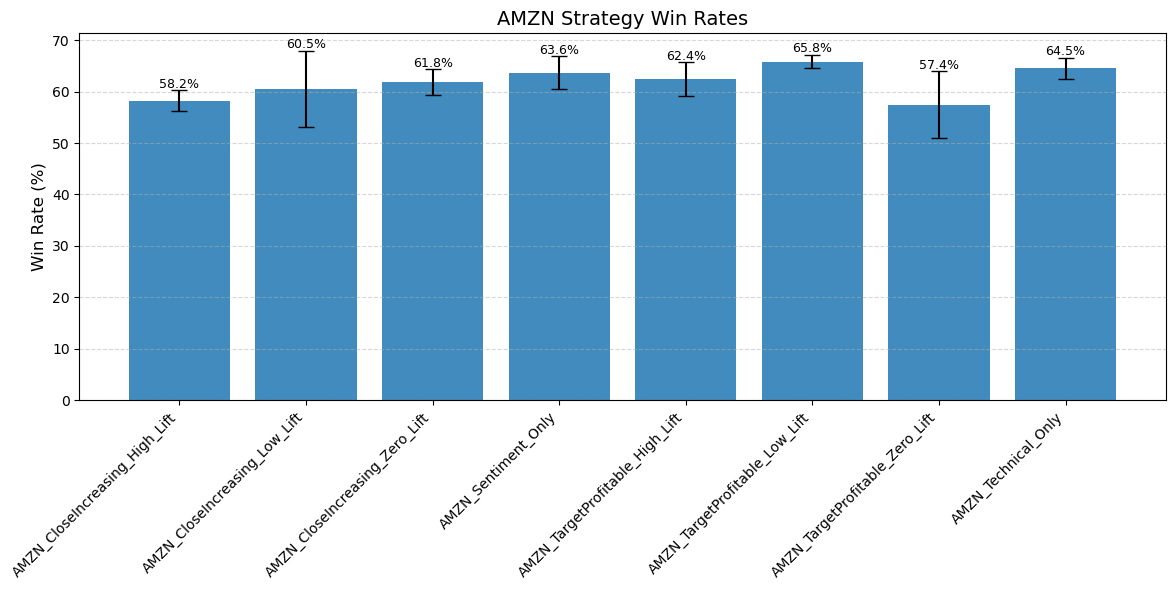

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ============================
#  YOUR RESULTS GO HERE
# ============================

results_amzn = dict(zip(amzn.index, amzn.values))

# Example: you can repeat these for BTC and MSFT
# (simply call the plotting function separately)

# ============================
#  PLOTTING FUNCTION
# ============================

def plot_winrate_barplot(result_dict, title, save_path=None):
    labels = list(result_dict.keys())
    means = [result_dict[k][0] for k in labels]
    stds = [result_dict[k][1] for k in labels]

    x = np.arange(len(labels))

    plt.figure(figsize=(12, 6))
    plt.bar(x, means, yerr=stds, capsize=6, alpha=0.85)

    plt.xticks(x, labels, rotation=45, ha='right', fontsize=10)
    plt.ylabel("Win Rate (%)", fontsize=12)
    plt.title(title, fontsize=14)
    plt.grid(axis='y', linestyle='--', alpha=0.5)

    # Add value labels
    for i, (m, s) in enumerate(zip(means, stds)):
        plt.text(i, m + s + 0.5, f"{m:.1f}%", ha='center', fontsize=9)

    plt.tight_layout()

    # Save to file if needed
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.show()
plot_winrate_barplot(results_amzn, "AMZN Strategy Win Rates")